In [1]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("PyTorch version: ", torch.__version__)
print("CUDA available: ", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

PyTorch version:  2.11.0+cu130
CUDA available:  True
Using device:  cuda


# 1. Dataset Selection

In [2]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_ROOT = "/content/drive/MyDrive/Brain Tumor MRI "
SOURCE_TRAIN_DIR = os.path.join(DATASET_ROOT, "Training")

CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

SAMPLES_PER_CLASS = 100
TRAIN_PER_CLASS = 70
VAL_PER_CLASS = 15
TEST_PER_CLASS = 15

print("Dataset path: ", DATASET_ROOT)
print("Training path: ", SOURCE_TRAIN_DIR)

Dataset path:  /content/drive/MyDrive/Brain Tumor MRI 
Training path:  /content/drive/MyDrive/Brain Tumor MRI /Training


In [4]:
# Check whether the folders exist

print("Training folder  exists: ", os.path.exists(SOURCE_TRAIN_DIR))

for cls in CLASSES:
    class_path = os.path.join(SOURCE_TRAIN_DIR, cls)
    print(f"{cls:12s} -> {len(os.listdir(class_path)) if os.path.exists(class_path) else 'FOLDER NOT FOUND'} images")

Training folder  exists:  True
glioma       -> 1400 images
meningioma   -> 1400 images
notumor      -> 1401 images
pituitary    -> 1417 images


# 2. Dataset Preparation

In [5]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

WORKING_DIR = "/content/brain_tumor_100"

# Remove an old copy if it exists
if os.path.exists(WORKING_DIR):
    shutil.rmtree(WORKING_DIR)

for split in ["train", "val", "test"]:
    for cls in CLASSES:
        os.makedirs(os.path.join(WORKING_DIR, split, cls), exist_ok=True)

# Supported image extensions
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for cls in CLASSES:
    source_class_dir = os.path.join(SOURCE_TRAIN_DIR, cls)

    image_files = [
        f for f in os.listdir(source_class_dir)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ]

    random.shuffle(image_files)

    if len(image_files) < SAMPLES_PER_CLASS:
        raise ValueError(
            f"{cls} has only {len(image_files)} images, "
            f"but {SAMPLES_PER_CLASS} are required."
        )

    selected = image_files[:SAMPLES_PER_CLASS]

    train_files = selected[:TRAIN_PER_CLASS]
    val_files = selected[TRAIN_PER_CLASS:TRAIN_PER_CLASS + VAL_PER_CLASS]
    test_files = selected[TRAIN_PER_CLASS + VAL_PER_CLASS:]

    splits = {
        "train": train_files,
        "val": val_files,
        "test": test_files
    }

    for split, files in splits.items():
        for filename in files:
            src = os.path.join(source_class_dir, filename)
            dst = os.path.join(WORKING_DIR, split, cls, filename)
            shutil.copy2(src, dst)

print("Dataset preparation completed!")

Dataset preparation completed!


In [6]:
# Verify exactly how many images we have

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    total = 0

    for cls in CLASSES:
        folder = os.path.join(WORKING_DIR, split, cls)
        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith(IMAGE_EXTENSIONS)
        ])
        total += count
        print(f"{cls:12s}: {count}")

    print("Total: ", total)


TRAIN
glioma      : 70
meningioma  : 70
notumor     : 70
pituitary   : 70
Total:  280

VAL
glioma      : 15
meningioma  : 15
notumor     : 15
pituitary   : 15
Total:  60

TEST
glioma      : 15
meningioma  : 15
notumor     : 15
pituitary   : 15
Total:  60


# 3. Data Preprocessing

In [7]:
IMAGE_SIZE = 128
BATCH_SIZE = 16

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std = [0.5, 0.5, 0.5]
    )
])

# 4. Data Augmentation

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std = [0.5, 0.5, 0.5]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std = [0.5, 0.5, 0.5]
    )
])

In [9]:
# create dataset

train_dataset = datasets.ImageFolder(
    os.path.join(WORKING_DIR, "train"),
    transform = train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(WORKING_DIR, "val"),
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(WORKING_DIR, "test"),
    transform=eval_transform
)

print("Class names:", train_dataset.classes)
print("Class-to-index:", train_dataset.class_to_idx)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class-to-index: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train: 280
Validation: 60
Test: 60


In [10]:
# create dataloader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle = False,
    num_workers=2
)

print("DataLoaders ready!")

DataLoaders ready!


# 5. CNN Model Architecture

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # 3 * 128 * 128
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 16 * 64 * 64
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 32 * 32 * 32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
            #64 * 16 * 16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=len(CLASSES)).to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [12]:
# Count trainable parameters

total_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print("Trainable parameters: ", total_params)

Trainable parameters:  2121380


# 6. Model Training

In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001
)

EPOCHS = 15

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [15]:
def train_one_epich(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0.0
    total = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [17]:
# Training loop

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epich(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [01/15] | Train Loss: 0.3716 | Train Acc: 0.8536 | Val Loss: 0.4498 | Val Acc: 0.8000
Epoch [02/15] | Train Loss: 0.4067 | Train Acc: 0.8107 | Val Loss: 0.4462 | Val Acc: 0.8333
Epoch [03/15] | Train Loss: 0.4080 | Train Acc: 0.8571 | Val Loss: 0.5268 | Val Acc: 0.8000
Epoch [04/15] | Train Loss: 0.3345 | Train Acc: 0.8679 | Val Loss: 0.4146 | Val Acc: 0.8333
Epoch [05/15] | Train Loss: 0.3356 | Train Acc: 0.8679 | Val Loss: 0.4686 | Val Acc: 0.8167
Epoch [06/15] | Train Loss: 0.3357 | Train Acc: 0.8679 | Val Loss: 0.5575 | Val Acc: 0.8000
Epoch [07/15] | Train Loss: 0.3843 | Train Acc: 0.8429 | Val Loss: 0.4879 | Val Acc: 0.8167
Epoch [08/15] | Train Loss: 0.3595 | Train Acc: 0.8643 | Val Loss: 0.3416 | Val Acc: 0.8333
Epoch [09/15] | Train Loss: 0.2936 | Train Acc: 0.8929 | Val Loss: 0.4637 | Val Acc: 0.8167
Epoch [10/15] | Train Loss: 0.2956 | Train Acc: 0.8821 | Val Loss: 0.4602 | Val Acc: 0.8000
Epoch [11/15] | Train Loss: 0.2468 | Train Acc: 0.9107 | Val Loss: 0.4403 | Val 

Training Curve

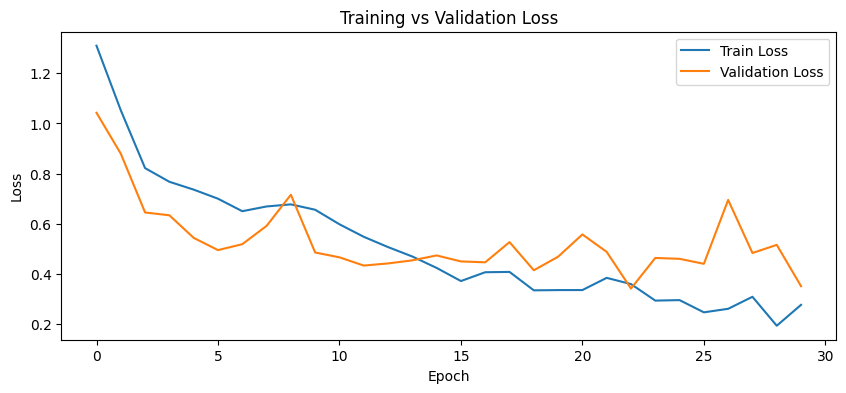

In [18]:
plt.figure(figsize=(10, 4))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

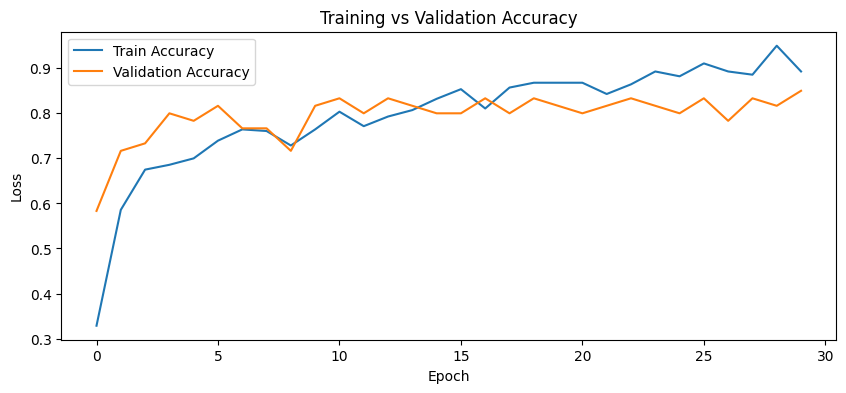

In [19]:
plt.figure(figsize=(10, 4))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

7. Model Evaluation

In [20]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        prediction = torch.argmax(outputs, dim=1)

        all_predictions.extend(prediction.cpu().numpy())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

test_accuracy = (all_predictions == all_labels).mean()

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7333


In [21]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes,
        digits = 4
    )
)

              precision    recall  f1-score   support

      glioma     0.8333    0.6667    0.7407        15
  meningioma     0.5263    0.6667    0.5882        15
     notumor     0.8571    0.8000    0.8276        15
   pituitary     0.8000    0.8000    0.8000        15

    accuracy                         0.7333        60
   macro avg     0.7542    0.7333    0.7391        60
weighted avg     0.7542    0.7333    0.7391        60



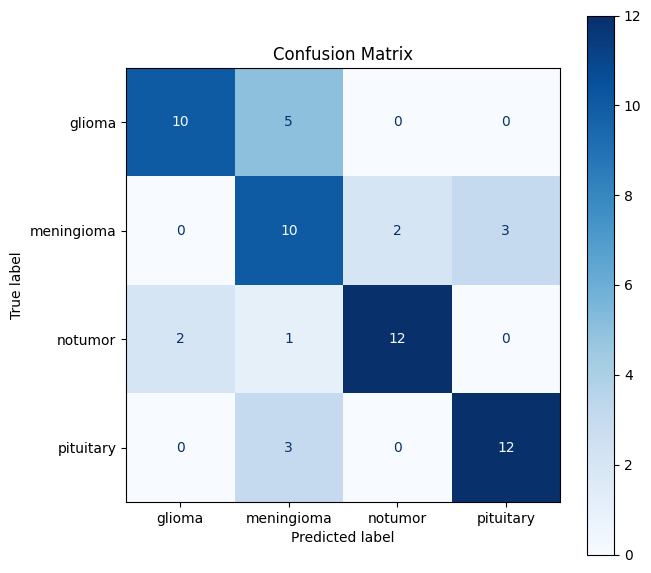

In [23]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

8. Prediction & Inference

In [24]:
def predict_image(model, image_path, class_names, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")

    # Same preprocessing used for validation/test
    input_tensor = eval_transform(image)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)

        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, dim=1)

    predicted_class = class_names[predicted_idx.item()]
    confidence = confidence.item()

    return image, predicted_class, confidence, probabilities.cpu().numpy()[0]

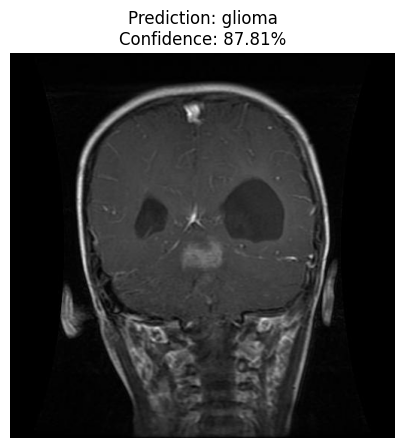

Image: /content/brain_tumor_100/test/glioma/Tr-gl_111.jpg
Predicted class: glioma
Confidence: 87.81%

Class probabilities:
glioma      : 87.81%
meningioma  : 11.38%
notumor     : 0.38%
pituitary   : 0.43%


In [25]:
# Pick one test image automatically

sample_path = test_dataset.samples[0][0]

image, predicted_class, confidence, probabilities = predict_image(
    model,
    sample_path,
    test_dataset.classes,
    device
)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2%}"
)
plt.axis("off")
plt.show()

print("Image:", sample_path)
print("Predicted class:", predicted_class)
print("Confidence:", f"{confidence:.2%}")

print("\nClass probabilities:")
for class_name, prob in zip(test_dataset.classes, probabilities):
    print(f"{class_name:12s}: {prob:.2%}")